# Notebook 3 — Train, Validation & Test

**Sprint 7 — Machine Learning Fundamentals for AI/ML Engineers**

**Dataset note:** The Sprint 6 dataset was not available to me while preparing this notebook, so I am using two standard scikit-learn datasets consistently across Notebooks 3–6 so the workflow stays comparable:

- **Classification target:** Breast Cancer Wisconsin dataset (`sklearn.datasets.load_breast_cancer`) — predicting malignant vs benign tumors.
- **Regression target:** Diabetes dataset (`sklearn.datasets.load_diabetes`) — predicting a quantitative measure of disease progression.

Both are bundled with scikit-learn, well documented, and have a genuinely meaningful target variable (not chosen because they produce a high score).

## Step 1 — Understand the Concept

### Why do we split data at all?

The entire point of a Machine Learning model is to perform well on data it has **never seen before**. If we only ever check how well the model does on the data it was trained on, we learn nothing about whether it has actually *generalized* — it may have simply memorized the training examples.

So we deliberately hold back some data, and pretend the model has never seen it, to simulate "the future" or "the real world."

### Training Dataset
The portion of data the model directly **learns from**. The algorithm adjusts its internal parameters (coefficients, tree splits, etc.) to fit this data.

### Validation Dataset
A portion of data set aside **during development** to:
- Compare different models or algorithms
- Tune hyperparameters (e.g., K in KNN, depth of a tree, C in SVM)
- Detect overfitting *before* touching the test set

The model does not learn from the validation set directly, but we *do* use it to make decisions about the model (which hyperparameters to keep, which model to prefer). This means the validation set indirectly influences the final model.

### Test Dataset
Data that is touched **exactly once**, at the very end, to report a final, honest, unbiased estimate of how the model will perform in the real world. No decisions are made based on the test set — it is not used to pick hyperparameters, not used to pick between models, and not used to retrain.

### Why the test set must **never** be used for tuning
If you tune hyperparameters or select a model based on test set performance, the test set effectively becomes a second validation set. The score you report is no longer an honest estimate of real-world performance because you have "leaked" information from the test set into your modeling decisions. You will end up overestimating how well your model will do once deployed, because you have implicitly selected the model/hyperparameters that just happen to work well on that specific batch of test data.

**Rule of thumb:** train → tune using validation/cross-validation → touch test set once at the very end → report that number and stop.

### Train/Test Split
The simplest strategy: split data once into a training set and a test set (commonly 70/30, 80/20).

### Train/Validation/Test Split
A three-way split so hyperparameter tuning has its own dedicated slice of data, separate from the final test set (commonly 60/20/20).

### Cross Validation
Instead of relying on a single, possibly lucky/unlucky train/validation split, cross-validation repeats the train/validate process multiple times on different slices of the data and averages the results — giving a much more stable, trustworthy performance estimate.

### K-Fold Cross Validation
- Split the training data into **K** equal-sized "folds."
- For each of the K rounds, train on K−1 folds and validate on the remaining fold.
- Average the K validation scores.

Every data point gets used for validation exactly once and for training K−1 times.

### Stratified K-Fold
A variant of K-Fold used for **classification**, which makes sure each fold has approximately the same proportion of each class as the full dataset. This matters a lot for imbalanced datasets — a random fold could otherwise end up with very few (or zero) examples of the minority class.

### Random State
Many splitting and model-fitting operations involve randomness (which rows go where, random initialization, etc.). Setting a fixed `random_state` (a seed) makes the "random" split **reproducible** — running the same code twice gives the same split, which is essential for fair comparisons and debugging.

### Data Leakage
Any situation where information from outside the training set (typically from the validation or test set, or from the future) improperly influences training. Examples:
- Scaling/normalizing the *entire* dataset before splitting (the scaler "sees" the test data's distribution).
- Performing feature selection using the whole dataset before splitting.
- Duplicate rows split across train and test.

Data leakage makes offline metrics look better than the model will actually perform in production.

### Overfitting
The model learns the training data *too well*, including its noise and quirks. It performs great on training data but poorly on unseen data. Symptom: training score ≫ validation/test score.

### Underfitting
The model is too simple to capture the real pattern in the data. It performs poorly on both training and unseen data. Symptom: training score is already low.

## Step 2 — Demonstrate the Concept

**Simple example:** Imagine studying for an exam using a set of 100 practice questions (training set). If the real exam reuses the exact same 100 questions, scoring 100% tells you nothing about whether you understand the subject — you may have memorized answers. A *fair* exam uses new questions (test set) you have never seen.

**Real-world / business example:** A bank builds a credit-default model using 5 years of loan history. It trains on 2019–2022 data, validates/tunes on early 2023 data, and finally checks performance on late 2023–2024 data it never touched during development — simulating how the model will behave on *future* loan applicants.

**AI/ML use case:** In our breast cancer classification problem, we train on a subset of patients, use a validation split (or cross-validation) to decide, say, whether Logistic Regression or KNN generalizes better, and only then evaluate the chosen model on the untouched test set to report a final, trustworthy accuracy/F1 score.

**Mathematical intuition:** If a model has learned the true underlying relationship `f(X) -> y`, its error on unseen data drawn from the same distribution should be close to its error on the training data. A large *gap* between training error and validation/test error is direct numeric evidence of overfitting.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, cross_val_score
)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier

np.random.seed(42)

# ---- Load both datasets ----
cancer = load_breast_cancer(as_frame=True)
X_clf, y_clf = cancer.data, cancer.target

diabetes = load_diabetes(as_frame=True)
X_reg, y_reg = diabetes.data, diabetes.target

print("Classification dataset (Breast Cancer):", X_clf.shape, " Target classes:", np.unique(y_clf))
print("Regression dataset (Diabetes):        ", X_reg.shape, " Target range:", y_reg.min(), "-", y_reg.max())

Classification dataset (Breast Cancer): (569, 30)  Target classes: [0 1]
Regression dataset (Diabetes):         (442, 10)  Target range: 25.0 - 346.0


### 3.1 Simple Train/Test Split

In [3]:
# Simple 80/20 train/test split, stratified on the target for classification
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])
print("\nClass balance in full data:  ", y_clf.value_counts(normalize=True).round(3).to_dict())
print("Class balance in train split:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Class balance in test split: ", y_test.value_counts(normalize=True).round(3).to_dict())

Train size: 455
Test size : 114

Class balance in full data:   {1: 0.627, 0: 0.373}
Class balance in train split: {1: 0.626, 0: 0.374}
Class balance in test split:  {1: 0.632, 0: 0.368}


### 3.2 Train/Validation/Test Split (three-way)

We split off the test set first (and lock it away), then split the *remaining* data into train and validation.

In [4]:
# Step 1: split off the final test set (20%) - this is NOT touched again until the very end
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=42, stratify=y_clf
)

# Step 2: split the remaining 80% into train (75% of it) and validation (25% of it)
# -> overall: 60% train / 20% validation / 20% test
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

print(f"Train:      {X_train.shape[0]} rows ({X_train.shape[0]/len(X_clf):.0%})")
print(f"Validation: {X_val.shape[0]} rows ({X_val.shape[0]/len(X_clf):.0%})")
print(f"Test:       {X_test.shape[0]} rows ({X_test.shape[0]/len(X_clf):.0%})")

Train:      341 rows (60%)
Validation: 114 rows (20%)
Test:       114 rows (20%)


# Use validation set to make a modeling decision: compare two candidate models.
# NOTE: the test set is not used here at all.
model_a = LogisticRegression(max_iter=5000).fit(X_train, y_train)
model_b = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)

acc_a = model_a.score(X_val, y_val)
acc_b = model_b.score(X_val, y_val)

print(f"Logistic Regression validation accuracy: {acc_a:.4f}")
print(f"Decision Tree (depth=3) validation accuracy: {acc_b:.4f}")

chosen = model_a if acc_a >= acc_b else model_b
print("\nModel chosen based on VALIDATION performance:", type(chosen).__name__)

# Only NOW, after the decision is made, do we touch the test set - exactly once.
final_test_acc = chosen.score(X_test, y_test)
print(f"Final, one-time TEST accuracy of chosen model: {final_test_acc:.4f}")

### 3.3 Random State — reproducibility

The same split code, run with the same `random_state`, always produces the same partition. Changing the seed changes the partition (and can change your validation score slightly, which is exactly why cross-validation is preferred over a single split for reporting/tuning decisions).

In [6]:
for seed in [1, 42, 42, 7]:
    _, _, y_tr, y_te = train_test_split(X_clf, y_clf, test_size=0.2, random_state=seed, stratify=y_clf)
    print(f"random_state={seed:<3} -> first 5 test-set labels: {y_te.values[:5]}")

random_state=1   -> first 5 test-set labels: [1 0 1 1 0]
random_state=42  -> first 5 test-set labels: [0 1 0 1 0]
random_state=42  -> first 5 test-set labels: [0 1 0 1 0]
random_state=7   -> first 5 test-set labels: [0 0 1 0 1]


### 3.4 K-Fold Cross Validation

In [8]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_scores = []
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_clf), start=1):
    X_tr, X_val_fold = X_clf.iloc[train_idx], X_clf.iloc[val_idx]
    y_tr, y_val_fold = y_clf.iloc[train_idx], y_clf.iloc[val_idx]

    model = LogisticRegression(max_iter=5000).fit(X_tr, y_tr)
    score = model.score(X_val_fold, y_val_fold)
    fold_scores.append(score)
    print(f"Fold {fold_idx}: train size={len(train_idx):3d}, val size={len(val_idx):3d}, accuracy={score:.4f}")

print(f"\nMean CV accuracy: {np.mean(fold_scores):.4f}  (std: {np.std(fold_scores):.4f})")

Fold 1: train size=455, val size=114, accuracy=0.9561
Fold 2: train size=455, val size=114, accuracy=0.9649
Fold 3: train size=455, val size=114, accuracy=0.9386
Fold 4: train size=455, val size=114, accuracy=0.9737
Fold 5: train size=456, val size=113, accuracy=0.9204

Mean CV accuracy: 0.9507  (std: 0.0191)


### 3.5 Stratified K-Fold — why it matters for classification

Plain `KFold` shuffles rows randomly into folds and can, by chance, create folds with a different class balance than the full dataset — especially risky on imbalanced data. `StratifiedKFold` preserves the class proportions in every fold.

In [9]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Overall class balance:", y_clf.value_counts(normalize=True).round(3).to_dict())
print()
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_clf, y_clf), start=1):
    val_balance = y_clf.iloc[val_idx].value_counts(normalize=True).round(3).to_dict()
    print(f"Stratified Fold {fold_idx} validation class balance: {val_balance}")

Overall class balance: {1: 0.627, 0: 0.373}

Stratified Fold 1 validation class balance: {1: 0.623, 0: 0.377}
Stratified Fold 2 validation class balance: {1: 0.623, 0: 0.377}
Stratified Fold 3 validation class balance: {1: 0.632, 0: 0.368}
Stratified Fold 4 validation class balance: {1: 0.632, 0: 0.368}
Stratified Fold 5 validation class balance: {1: 0.628, 0: 0.372}


In [10]:
# Convenience: sklearn's cross_val_score does the loop above for us
scores = cross_val_score(
    LogisticRegression(max_iter=5000), X_clf, y_clf,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="accuracy"
)
print("Per-fold accuracy:", np.round(scores, 4))
print(f"Mean: {scores.mean():.4f}  Std: {scores.std():.4f}")

Per-fold accuracy: [0.9649 0.9211 0.9649 0.9474 0.9735]
Mean: 0.9543  Std: 0.0187


### 3.6 Demonstrating Data Leakage (and why it inflates scores)

Here we deliberately do it **wrong** first (scale before splitting, using information from the whole dataset including the test rows), then do it **right** (fit the scaler only on training data). The wrong version doesn't always look dramatically different on a clean dataset like this one, but the principle is what matters: any transformation that "sees" test data before the split is leakage.

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# ---- WRONG: fit scaler on the ENTIRE dataset before splitting ----
scaler_leaky = StandardScaler().fit(X_clf)          # sees ALL rows, including future test rows
X_scaled_leaky = scaler_leaky.transform(X_clf)

X_tr_leak, X_te_leak, y_tr_leak, y_te_leak = train_test_split(
    X_scaled_leaky, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
model_leaky = KNeighborsClassifier(n_neighbors=5).fit(X_tr_leak, y_tr_leak)
acc_leaky = model_leaky.score(X_te_leak, y_te_leak)

# ---- RIGHT: split first, fit scaler ONLY on training data ----
X_tr_ok, X_te_ok, y_tr_ok, y_te_ok = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
scaler_ok = StandardScaler().fit(X_tr_ok)            # only sees training rows
X_tr_ok_scaled = scaler_ok.transform(X_tr_ok)
X_te_ok_scaled = scaler_ok.transform(X_te_ok)          # test rows transformed using TRAIN statistics

model_ok = KNeighborsClassifier(n_neighbors=5).fit(X_tr_ok_scaled, y_tr_ok)
acc_ok = model_ok.score(X_te_ok_scaled, y_te_ok)

print(f"Leaky pipeline (scaled before split)  test accuracy: {acc_leaky:.4f}")
print(f"Correct pipeline (scaled after split) test accuracy: {acc_ok:.4f}")

Leaky pipeline (scaled before split)  test accuracy: 0.9649
Correct pipeline (scaled after split) test accuracy: 0.9561


### 3.7 Demonstrating Overfitting vs Underfitting

We vary the depth of a Decision Tree — a very shallow tree underfits, a very deep tree overfits — and plot training accuracy vs cross-validated (validation) accuracy at each depth.

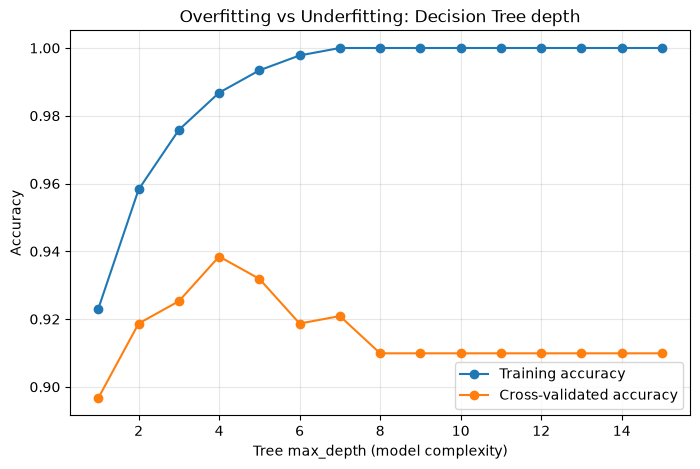

Training accuracy by depth:   [0.923 0.958 0.976 0.987 0.993 0.998 1.    1.    1.    1.    1.    1.
 1.    1.    1.   ]
Validation accuracy by depth: [0.897 0.919 0.925 0.938 0.932 0.919 0.921 0.91  0.91  0.91  0.91  0.91
 0.91  0.91  0.91 ]


In [12]:
depths = range(1, 16)
train_scores, val_scores = [], []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train_full, y_train_full)
    train_scores.append(tree.score(X_train_full, y_train_full))

    cv_scores = cross_val_score(tree, X_train_full, y_train_full, cv=5)
    val_scores.append(cv_scores.mean())

plt.figure(figsize=(8, 5))
plt.plot(list(depths), train_scores, marker='o', label='Training accuracy')
plt.plot(list(depths), val_scores, marker='o', label='Cross-validated accuracy')
plt.xlabel('Tree max_depth (model complexity)')
plt.ylabel('Accuracy')
plt.title('Overfitting vs Underfitting: Decision Tree depth')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Training accuracy by depth:  ", np.round(train_scores, 3))
print("Validation accuracy by depth:", np.round(val_scores, 3))

## Step 4 — Interpret the Result

**Reading the depth plot:**
- **Depth 1–2 (underfitting region):** Both training and validation accuracy are relatively low and close together. The tree is too simple to capture the real pattern — it hasn't even learned the training data well, so of course it can't generalize either.
- **Middle depths:** Training accuracy climbs and validation accuracy climbs too, and the two curves stay close — this is the "good fit" region where the model is learning real signal that generalizes.
- **Higher depths (overfitting region):** Training accuracy keeps climbing towards ~100%, but validation accuracy flattens or starts dropping. The growing **gap** between the two curves is the signature of overfitting — the tree is memorizing quirks of the training rows that don't exist in new data.

**On the leakage experiment:** Even though the difference between the leaky and correct pipeline may look small on this particular clean, well-behaved dataset, that is exactly the danger of leakage — it doesn't always announce itself with a dramatic number. On noisier or smaller real-world datasets the inflation can be large and completely misleading about production performance. The safe habit (fit any transformer only on training data, always) costs nothing and prevents a class of bugs that are otherwise very hard to detect.

**On cross-validation vs a single split:** Note the *std* reported alongside the mean CV accuracy. A single train/test split gives you one number with no sense of how much that number might have varied with a different random split. Cross-validation's standard deviation tells you how *stable* the model's performance is — a small std means the model behaves consistently across different subsets of data; a large std is a warning sign (small dataset, high variance model, or an unstable feature).

**Why we never touched the test set until the very end:** In the three-way split example, the decision of *which model to use* (Logistic Regression vs Decision Tree) was made purely from validation accuracy. The test accuracy reported afterward is therefore a genuinely unbiased estimate of how the chosen model will perform on new, unseen data — because the test set played no role whatsoever in choosing it.